In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import cv2


In [2]:
# Load the dataset
df = pd.read_csv('C:/Users/HP/Desktop/output_pose_data_012215.csv')

In [3]:
# Inspect the data
print(df.head())

     Label  left_elbow_angle  right_elbow_angle  left_shoulder_angle  \
0  Downdog        193.134022         190.988969           180.481466   
1  Downdog        173.021603         163.422875           188.310824   
2  Downdog        170.896126         162.897271           170.499964   
3  Downdog        173.353235         175.751699           190.560267   
4  Downdog        195.660672         186.818215           195.660672   

   right_shoulder_angle  left_knee_angle  right_knee_angle  
0            181.041627       185.732217        187.807702  
1            179.937609       182.174744        183.366461  
2            192.073831       175.558659        172.255582  
3            168.231184       178.090848        180.344632  
4            161.565051       189.573307        191.213603  


In [7]:
# Check for non-numeric columns
non_numeric_columns = df.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_columns)

Non-numeric columns: Index(['Label'], dtype='object')


In [8]:
# Handle non-numeric columns if any (for this example, we'll drop them)
df = df.drop(columns=non_numeric_columns)

In [9]:
# Assuming the last column is the label indicating correctness (1 for correct, 0 for incorrect)
X = df.iloc[:, :-1].values  # Features: all columns except the last
y = df.iloc[:, -1].values   # Labels: the last column

In [15]:
# Ensure that labels are integers
y = y.astype(int)

In [16]:
# Check if the labels column needs to be converted to numeric
if y.dtype == 'object':
    y = np.where(y == 'correct', 1, 0)

In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Initialize the model
model = LogisticRegression()

In [20]:
# Train the model
model.fit(X_train, y_train)

LogisticRegression()

In [21]:
# Make predictions
y_pred = model.predict(X_test)

In [22]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
              precision    recall  f1-score   support

          24       0.00      0.00      0.00         1
          25       0.00      0.00      0.00         3
          26       0.00      0.00      0.00         2
          27       0.00      0.00      0.00         0
          28       0.00      0.00      0.00         0
          30       0.00      0.00      0.00         3
          31       0.00      0.00      0.00         1
          33       0.00      0.00      0.00         1
          34       0.00      0.00      0.00         1
          35       0.00      0.00      0.00         2
          40       0.00      0.00      0.00         1
          53       0.00      0.00      0.00         1
          60       0.00      0.00      0.00         1
          66       0.00      0.00      0.00         1
          83       0.00    

C:\Users\HP\anaconda3\envs\mediapipe\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\mediapipe\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\mediapipe\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\

In [27]:
# Plotting the confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm[np.isnan(cm)] = 0  # Avoid division by zero

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [28]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

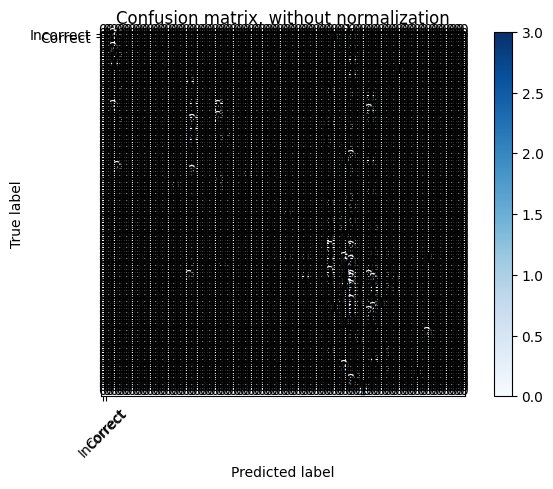

In [29]:
# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Incorrect', 'Correct'],
                      title='Confusion matrix, without normalization')

C:\Users\HP\AppData\Local\Temp\ipykernel_8480\192189207.py:11: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


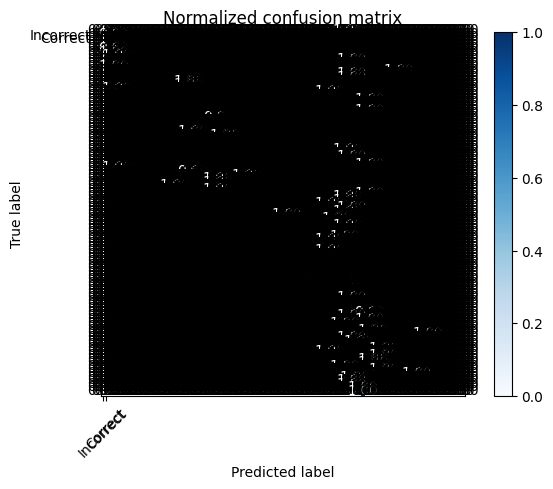

In [30]:
# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Incorrect', 'Correct'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

In [34]:
# Read an input image
image_path = 'C:/Users/HP/Desktop/test_1.jpg'
image = cv2.imread(image_path)

In [2]:
import joblib
from sklearn.linear_model import LogisticRegression

# Assuming you have trained a logistic regression model named 'model'
model = LogisticRegression()
# Train the model...
# model.fit(X_train, y_train)

# Save the trained model
joblib.dump(model, 'pose_verification_model.pkl')

['pose_verification_model.pkl']

In [9]:
import pandas as pd

# Assuming you have a CSV file containing your training data
# Load the CSV file into a DataFrame
data = pd.read_csv('C:/Users/HP/Desktop/output_pose_data_012215.csv')

# Extract features (X_train) and labels (y_train) from the DataFrame
X_train = data.drop(columns=['Label'])  # Assuming 'label' column contains the target variable
y_train = data['Label']  # Assuming 'label' column contains the target variable

# Now you can scale your features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# After scaling, you can proceed with training your model and saving the scaler
# Train your model...
# Save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']